- [https://nlp.seas.harvard.edu/annotated-transformer/](https://nlp.seas.harvard.edu/annotated-transformer/)

In [2]:
from IPython.display import display, HTML

display(HTML(r"""
<style>
/* JupyterLab 4.x: center the notebook area */
.jp-NotebookPanel-notebook,
.jp-NotebookPanel .jp-Notebook {
  width: 85% !important;
  max-width: 1100px !important;
  margin: 0 auto !important;
}

/* Make wide outputs scroll instead of breaking the layout */
.jp-OutputArea-output {
  overflow-x: auto !important;
}
</style>
"""))

%config InlineBackend.figure_format = "svg"
print("Centered JupyterLab notebook + SVG inline figures.")

Centered JupyterLab notebook + SVG inline figures.


In [3]:
import os
import time
from detect_torch_device import detect_torch_device
device = detect_torch_device()

os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
os.environ["HF_HOME"] = "/inspire/hdd/project/fdu-aidake-cfff/public/hf-home"
print(os.environ.get("HF_ENDPOINT"))

jnk_start_time = time.time()

numpy: 2.4.3
torch: 2.7.1
cuda devices: 1
  [0] NVIDIA A100-SXM4-80GB
https://hf-mirror.com


In [4]:
import os
from os.path import exists
import torch
import torch.nn as nn
from torch.nn.functional import log_softmax, pad
import math
import copy
import time
from torch.optim.lr_scheduler import LambdaLR
import pandas as pd
import altair as alt
from torch.utils.data import DataLoader
import spacy
import warnings
from torch.utils.data.distributed import DistributedSampler
import torch.distributed as dist
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP


# Set to False to skip notebook execution (e.g. for debugging)
warnings.filterwarnings("ignore")
RUN_EXAMPLES = True

In [5]:
# Some convenience helper functions used throughout the notebook
def is_interactive_notebook():
    return __name__ == "__main__"

def show_example(fn, args=[]):
    if __name__ == "__main__" and RUN_EXAMPLES:
        return fn(*args)

def execute_example(fn, args=[]):
    if __name__ == "__main__" and RUN_EXAMPLES:
        fn(*args)

class DummyOptimizer(torch.optim.Optimizer):
    def __init__(self):
        self.param_groups = [{"lr": 0}]
        None

    def step(self):
        None

    def zero_grad(self, set_to_none=False):
        None

class DummyScheduler:
    def step(self):
        None

<a id=1></a>
### 1. Introduction

Recurrent neural networks, long short-term memory [13] and gated recurrent [7] neural networks in particular, have been firmly established as state of the art approaches in sequence modeling and transduction problems such as language modeling and machine translation [35, 2, 5]. Numerous efforts have since continued to push the boundaries of recurrent language models and encoder-decoder architectures [38, 24, 15].

Recurrent models typically factor computation along the symbol positions of the input and output sequences. Aligning the positions to steps in computation time, they generate a sequence of hidden states $h_t$, as a function of the previous hidden state $h_{t-1}$ and the input for position $t$. This inherently sequential nature precludes parallelization within training examples, which becomes critical at longer sequence lengths, as memory constraints limit batching across examples. Recent work has achieved significant improvements in computational efficiency through factorization tricks [21] and conditional computation [32], while also improving model performance in case of the latter. The fundamental constraint of sequential computation, however, remains.

Attention mechanisms have become an integral part of compelling sequence modeling and transduction models in various tasks, allowing modeling of dependencies without regard to their distance in the input or output sequences [2, 19]. In all but a few cases [27], however, such attention mechanisms are used in conjunction with a recurrent network.
In this work we propose the Transformer, a model architecture eschewing recurrence and instead relying entirely on an attention mechanism to draw global dependencies between input and output. The Transformer allows for significantly more parallelization and can reach a new state of the art in translation quality after being trained for as little as twelve hours on eight P100 GPUs.

<a id=1></a>
### 2. Background

The goal of reducing sequential computation also forms the foundation of the [Extended Neural GPU](https://baojian.github.io/llm-26/papers/Unigram-Subword_Regularization_Improving_Neural_Network_Translation_Models_with_Multiple_Subword_Candidates-2018.pdf), ByteNet [18] and ConvS2S [9], all of which use convolutional neural networks as basic building block, computing hidden representations in parallel for all input and output positions. In these models, the number of operations required to relate signals from two arbitrary input or output positions grows in the distance between positions, linearly for ConvS2S and logarithmically for ByteNet. This makes it more difficult to learn dependencies between distant positions [12]. In the Transformer this is reduced to a constant number of operations, albeit at the cost of reduced effective resolution due to averaging attention-weighted positions, an effect we counteract with Multi-Head Attention as described in section 3.2.

Self-attention, sometimes called intra-attention is an attention mechanism relating different positions of a single sequence in order to compute a representation of the sequence. Self-attention has been
used successfully in a variety of tasks including reading comprehension, abstractive summarization, textual entailment and learning task-independent sentence representations [4, 27, 28, 22]. End-to-end memory networks are based on a recurrent attention mechanism instead of sequencealigned recurrence and have been shown to perform well on simple-language question answering and language modeling tasks [34].

To the best of our knowledge, however, the Transformer is the first transduction model relying entirely on self-attention to compute representations of its input and output without using sequencealigned RNNs or convolution. In the following sections, we will describe the Transformer, motivate self-attention and discuss its advantages over models such as [17, 18] and [9].


<a id=2></a>
### 3. Model Architecture

Most competitive neural sequence transduction models have an encoder-decoder structure [5, 2, 35]. Here, the encoder maps an input sequence of symbol representations $\left(x_1, \ldots, x_n\right)$ to a sequence of continuous representations $\mathbf{z}=\left(z_1, \ldots, z_n\right)$. Given $\mathbf{z}$, the decoder then generates an output sequence $\left(y_1, \ldots, y_m\right)$ of symbols one element at a time. At each step the model is auto-regressive [10], consuming the previously generated symbols as additional input when generating the next.

In [6]:
class EncoderDecoder(nn.Module):
    """
    A standard Encoder-Decoder architecture. Base for this and many
    other models.
    """

    def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):
        super(EncoderDecoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.generator = generator

    def forward(self, src, tgt, src_mask, tgt_mask):
        "Take in and process masked src and target sequences."
        return self.decode(self.encode(src, src_mask), src_mask, tgt, tgt_mask)

    def encode(self, src, src_mask):
        return self.encoder(self.src_embed(src), src_mask)

    def decode(self, memory, src_mask, tgt, tgt_mask):
        return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask)

In [7]:
class Generator(nn.Module):
    "Define standard linear + softmax generation step."

    def __init__(self, d_model, vocab):
        super(Generator, self).__init__()
        self.proj = nn.Linear(d_model, vocab)

    def forward(self, x):
        return log_softmax(self.proj(x), dim=-1)

The Transformer follows this overall architecture using stacked self-attention and point-wise, fully connected layers for both the encoder and decoder, shown in the left and right halves of Figure 1, respectively.

<div style="text-align: center;">
  <img src="media/transformer-model.png" alt="Transformer model" width="600">
</div>

#### 3.1 Encoder and Decoder Stacks

> - **Encoder:** The encoder is composed of a stack of $N=6$ identical layers. Each layer has two sub-layers. The first is a multi-head self-attention mechanism, and the second is a simple, positionwise fully connected feed-forward network. We employ a residual connection [11] around each of the two sub-layers, followed by layer normalization [1]. That is, the output of each sub-layer is LayerNorm $(x+\operatorname{Sublayer}(x))$, where Sublayer $(x)$ is the function implemented by the sub-layer itself. To facilitate these residual connections, all sub-layers in the model, as well as the embedding layers, produce outputs of dimension $d_{\text {model }}=512$.

> - **Decoder:** The decoder is also composed of a stack of $N=6$ identical layers. In addition to the two sub-layers in each encoder layer, the decoder inserts a third sub-layer, which performs multi-head attention over the output of the encoder stack. Similar to the encoder, we employ residual connections around each of the sub-layers, followed by layer normalization. We also modify the self-attention sub-layer in the decoder stack to prevent positions from attending to subsequent positions. This masking, combined with fact that the output embeddings are offset by one position, ensures that the predictions for position $i$ can depend only on the known outputs at positions less than $i$.

- The encoder is composed of a stack of $N=6$ identical layers.

In [8]:
def clones(module, N):
    "Produce N identical layers."
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])
    
class Encoder(nn.Module):
    "Core encoder is a stack of N layers"

    def __init__(self, layer, N):
        super(Encoder, self).__init__()
        self.layers = clones(layer, N)
        self.norm = LayerNorm(layer.size)

    def forward(self, x, mask):
        "Pass the input (and mask) through each layer in turn."
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

- We employ a residual connection around each of the two sub-layers, followed by layer normalization.

In [9]:
class LayerNorm(nn.Module):
    "Construct a layernorm module (See citation for details)."

    def __init__(self, features, eps=1e-6):
        super(LayerNorm, self).__init__()
        self.a_2 = nn.Parameter(torch.ones(features))
        self.b_2 = nn.Parameter(torch.zeros(features))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.a_2 * (x - mean) / (std + self.eps) + self.b_2

- That is, the output of each sub-layer is LayerNorm $(x+\operatorname{Sublayer}(x))$, where Sublayer $(x)$ is the function implemented by the sub-layer itself. To facilitate these residual connections, all sub-layers in the model, as well as the embedding layers, produce outputs of dimension $d_{\text {model }}=512$.

In [10]:
class SublayerConnection(nn.Module):
    """
    A residual connection followed by a layer norm.
    Note for code simplicity the norm is first as opposed to last.
    """

    def __init__(self, size, dropout):
        super(SublayerConnection, self).__init__()
        self.norm = LayerNorm(size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, sublayer):
        "Apply residual connection to any sublayer with the same size."
        return x + self.dropout(sublayer(self.norm(x)))

- Each layer has two sub-layers. The first is a multi-head self-attention mechanism, and the second is a simple, position-wise fully connected feed-forward network.

In [11]:
class EncoderLayer(nn.Module):
    "Encoder is made up of self-attn and feed forward (defined below)"

    def __init__(self, size, self_attn, feed_forward, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = self_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 2)
        self.size = size

    def forward(self, x, mask):
        "Follow Figure 1 (left) for connections."
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, mask))
        return self.sublayer[1](x, self.feed_forward)

- The decoder is also composed of a stack of $N=6$ identical layers. 

In [12]:
class Decoder(nn.Module):
    "Generic N layer decoder with masking."

    def __init__(self, layer, N):
        super(Decoder, self).__init__()
        self.layers = clones(layer, N)
        self.norm = LayerNorm(layer.size)

    def forward(self, x, memory, src_mask, tgt_mask):
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.norm(x)

- In addition to the two sub-layers in each encoder layer, the decoder inserts a third sub-layer, which performs multi-head attention over the output of the encoder stack. Similar to the encoder, we employ residual connections around each of the sub-layers, followed by layer normalization.

In [13]:
class DecoderLayer(nn.Module):
    "Decoder is made of self-attn, src-attn, and feed forward (defined below)"

    def __init__(self, size, self_attn, src_attn, feed_forward, dropout):
        super(DecoderLayer, self).__init__()
        self.size = size
        self.self_attn = self_attn
        self.src_attn = src_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 3)

    def forward(self, x, memory, src_mask, tgt_mask):
        "Follow Figure 1 (right) for connections."
        m = memory
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, tgt_mask))
        x = self.sublayer[1](x, lambda x: self.src_attn(x, m, m, src_mask))
        return self.sublayer[2](x, self.feed_forward)

- We also modify the self-attention sub-layer in the decoder stack to prevent positions from attending to subsequent positions. This masking, combined with fact that the output embeddings are offset by one position, ensures that the predictions for position $i$ can depend only on the known outputs at positions less than $i$.

In [14]:
def subsequent_mask(size):
    "Mask out subsequent positions."
    attn_shape = (1, size, size)
    subsequent_mask = torch.triu(torch.ones(attn_shape), diagonal=1).type(
        torch.uint8
    )
    return subsequent_mask == 0

> Below the attention mask shows the position each tgt word (row) is allowed to look at (column). Words are blocked for attending to future words during training.

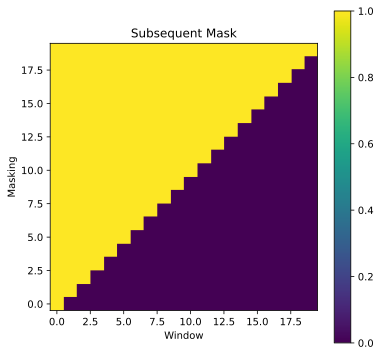

In [15]:
import matplotlib.pyplot as plt

def example_mask():
    mask = subsequent_mask(20)[0].cpu().numpy()

    plt.figure(figsize=(6, 6))
    plt.imshow(mask, origin="lower", aspect="equal")
    plt.xlabel("Window")
    plt.ylabel("Masking")
    plt.title("Subsequent Mask")
    plt.colorbar()
    plt.show()

example_mask()

<a id=32></a>
### 3.2 Attention

An attention function can be described as mapping a query and a set of key-value pairs to an output, where the query, keys, values, and output are all vectors. The output is computed as a weighted sum of the values, where the weight assigned to each value is computed by a compatibility function of the query with the corresponding key.

We call our particular attention "Scaled Dot-Product Attention". The input consists of queries and keys of dimension $d_k$, and values of dimension $d_v$. We compute the dot products of the query with all keys, divide each by $\sqrt{d_k}$, and apply a softmax function to obtain the weights on the values.


##### 3.2.1 Scaled Dot-Product Attention

We call our particular attention "Scaled Dot-Product Attention" (Figure 2). The input consists of queries and keys of dimension $d_k$, and values of dimension $d_v$. We compute the dot products of the query with all keys, divide each by $\sqrt{d_k}$, and apply a softmax function to obtain the weights on the values.

In practice, we compute the attention function on a set of queries simultaneously, packed together into a matrix $Q$. The keys and values are also packed together into matrices $K$ and $V$. We compute the matrix of outputs as:

$$
\operatorname{Attention}(Q, K, V)=\operatorname{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right) V
$$


<div style="text-align: center;">
  <img src="media/scaled-dot-product.png" alt="Transformer model" width="400">
</div>


The two most commonly used attention functions are additive attention [2], and dot-product (multiplicative) attention. Dot-product attention is identical to our algorithm, except for the scaling factor of $\frac{1}{\sqrt{d_k}}$. Additive attention computes the compatibility function using a feed-forward network with a single hidden layer. While the two are similar in theoretical complexity, dot-product attention is much faster and more space-efficient in practice, since it can be implemented using highly optimized matrix multiplication code.

While for small values of $d_k$ the two mechanisms perform similarly, additive attention outperforms dot product attention without scaling for larger values of $d_k$ [3]. We suspect that for large values of $d_k$, the dot products grow large in magnitude, pushing the softmax function into regions where it has extremely small gradients ${ }^4$. To counteract this effect, we scale the dot products by $\frac{1}{\sqrt{d_k}}$.

In [16]:
def attention(query, key, value, mask=None, dropout=None):
    "Compute 'Scaled Dot Product Attention'"
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    p_attn = scores.softmax(dim=-1)
    if dropout is not None:
        p_attn = dropout(p_attn)
    return torch.matmul(p_attn, value), p_attn

Instead of performing a single attention function with $d_{\text {model }}$-dimensional keys, values and queries, we found it beneficial to linearly project the queries, keys and values $h$ times with different, learned linear projections to $d_k, d_k$ and $d_v$ dimensions, respectively. On each of these projected versions of queries, keys and values we then perform the attention function in parallel, yielding $d_v$-dimensional output values. These are concatenated and once again projected, resulting in the final values, as depicted in Figure 2.

Multi-head attention allows the model to jointly attend to information from different representation subspaces at different positions. With a single attention head, averaging inhibits this.

$$
\begin{aligned}
\operatorname{MultiHead}(Q, K, V) & =\operatorname{Concat}\left(\operatorname{head}_1, \ldots, \operatorname{head}_{\mathrm{h}}\right) W^O \\
\text { where } \operatorname{head}_i & =\operatorname{Attention}\left(Q W_i^Q, K W_i^K, V W_i^V\right)
\end{aligned}
$$


Where the projections are parameter matrices $W_i^Q \in \mathbb{R}^{d_{\text {model }} \times d_k}, W_i^K \in \mathbb{R}^{d_{\text {model }} \times d_k}, W_i^V \in \mathbb{R}^{d_{\text {model }} \times d_v}$ and $W^O \in \mathbb{R}^{h d_v \times d_{\text {model }}}$.

In this work we employ $h=8$ parallel attention layers, or heads. For each of these we use $d_k=d_v=d_{\text {model }} / h=64$. Due to the reduced dimension of each head, the total computational cost is similar to that of single-head attention with full dimensionality.

<div style="text-align: center;">
  <img src="media/multi-head-attention.png" alt="Transformer model" width="400">
</div>

In [17]:
class MultiHeadedAttention(nn.Module):
    def __init__(self, h, d_model, dropout=0.1):
        "Take in model size and number of heads."
        super(MultiHeadedAttention, self).__init__()
        assert d_model % h == 0
        # We assume d_v always equals d_k
        self.d_k = d_model // h
        self.h = h
        self.linears = clones(nn.Linear(d_model, d_model), 4)
        self.attn = None
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, query, key, value, mask=None):
        "Implements Figure 2"
        if mask is not None:
            # Same mask applied to all h heads.
            mask = mask.unsqueeze(1)
        nbatches = query.size(0)

        # 1) Do all the linear projections in batch from d_model => h x d_k
        query, key, value = [
            lin(x).view(nbatches, -1, self.h, self.d_k).transpose(1, 2)
            for lin, x in zip(self.linears, (query, key, value))
        ]

        # 2) Apply attention on all the projected vectors in batch.
        x, self.attn = attention(
            query, key, value, mask=mask, dropout=self.dropout
        )

        # 3) "Concat" using a view and apply a final linear.
        x = (
            x.transpose(1, 2)
            .contiguous()
            .view(nbatches, -1, self.h * self.d_k)
        )
        del query
        del key
        del value
        return self.linears[-1](x)


### 3.2.3 Applications of Attention in our Model

The Transformer uses multi-head attention in three different ways:

- In "encoder-decoder attention" layers, the queries come from the previous decoder layer, and the memory keys and values come from the output of the encoder. This allows every position in the decoder to attend over all positions in the input sequence. This mimics the typical encoder-decoder attention mechanisms in sequence-to-sequence models such as [38, 2, 9].

- The encoder contains self-attention layers. In a self-attention layer all of the keys, values and queries come from the same place, in this case, the output of the previous layer in the encoder. Each position in the encoder can attend to all positions in the previous layer of the encoder.

- Similarly, self-attention layers in the decoder allow each position in the decoder to attend to all positions in the decoder up to and including that position. We need to prevent leftward information flow in the decoder to preserve the auto-regressive property. We implement this inside of scaled dot-product attention by masking out (setting to $-\infty$ ) all values in the input of the softmax which correspond to illegal connections. See Figure 2.

<a id=33></a>

### 3.3 Position-wise Feed-Forward Networks

In addition to attention sub-layers, each of the layers in our encoder and decoder contains a fully connected feed-forward network, which is applied to each position separately and identically. This consists of two linear transformations with a ReLU activation in between.

$$
\operatorname{FFN}(x)=\max \left(0, x W_1+b_1\right) W_2+b_2
$$


While the linear transformations are the same across different positions, they use different parameters from layer to layer. Another way of describing this is as two convolutions with kernel size 1. The dimensionality of input and output is $d_{\text {model }}=512$, and the inner-layer has dimensionality $d_{f f}=2048$.

In [18]:
class PositionwiseFeedForward(nn.Module):
    "Implements FFN equation."

    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(self.w_1(x).relu()))

<a id=34></a>
### 3.4 Embeddings and Softmax

Similarly to other sequence transduction models, we use learned embeddings to convert the input tokens and output tokens to vectors of dimension $d_{\text {model }}$. We also use the usual learned linear transformation and softmax function to convert the decoder output to predicted next-token probabilities. In our model, we share the same weight matrix between the two embedding layers and the pre-softmax linear transformation, similar to [30]. In the embedding layers, we multiply those weights by $\sqrt{d_{\text {model }}}$.

In [19]:
class Embeddings(nn.Module):
    def __init__(self, d_model, vocab):
        super(Embeddings, self).__init__()
        self.lut = nn.Embedding(vocab, d_model)
        self.d_model = d_model

    def forward(self, x):
        return self.lut(x) * math.sqrt(self.d_model)

<a id=35></a>
### 3.5 Positional Encoding

Since our model contains no recurrence and no convolution, in order for the model to make use of the order of the sequence, we must inject some information about the relative or absolute position of the tokens in the sequence. To this end, we add "positional encodings" to the input embeddings at the bottoms of the encoder and decoder stacks. The positional encodings have the same dimension $d_{\text {model }}$ as the embeddings, so that the two can be summed. There are many choices of positional encodings, learned and fixed [9].
In this work, we use sine and cosine functions of different frequencies:

$$
\begin{aligned}
P E_{(p o s, 2 i)} & =\sin \left(p o s / 10000^{2 i / d_{\text {model }}}\right) \\
P E_{(p o s, 2 i+1)} & =\cos \left(p o s / 10000^{2 i / d_{\text {model }}}\right)
\end{aligned}
$$

where pos is the position and $i$ is the dimension. That is, each dimension of the positional encoding corresponds to a sinusoid. The wavelengths form a geometric progression from $2 \pi$ to $10000 \cdot 2 \pi$. We chose this function because we hypothesized it would allow the model to easily learn to attend by relative positions, since for any fixed offset $k, P E_{\text {pos }+k}$ can be represented as a linear function of $P E_{\text {pos }}$.

We also experimented with using learned positional embeddings [9] instead, and found that the two versions produced nearly identical results (see Table 3 row (E)). We chose the sinusoidal version because it may allow the model to extrapolate to sequence lengths longer than the ones encountered during training.

In [20]:
class PositionalEncoding(nn.Module):
    "Implement the PE function."

    def __init__(self, d_model, dropout, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Compute the positional encodings once in log space.
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, : x.size(1)].requires_grad_(False)
        return self.dropout(x)

> Below the positional encoding will add in a sine wave based on position. The frequency and offset of the wave is different for each dimension.

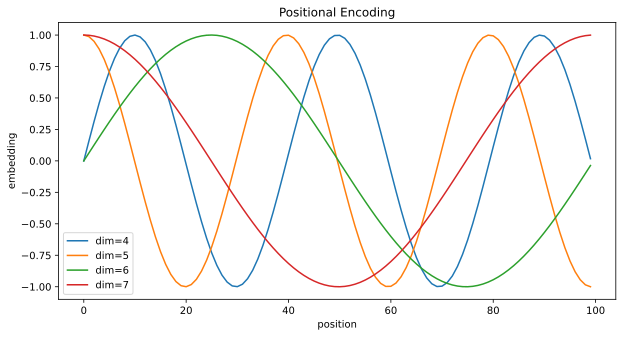

In [21]:
import matplotlib.pyplot as plt

def example_positional():
    pe = PositionalEncoding(20, 0)
    y = pe.forward(torch.zeros(1, 100, 20))

    positions = range(100)

    plt.figure(figsize=(10, 5))
    for dim in [4, 5, 6, 7]:
        plt.plot(positions, y[0, :, dim].cpu().numpy(), label=f"dim={dim}")

    plt.xlabel("position")
    plt.ylabel("embedding")
    plt.title("Positional Encoding")
    plt.legend()
    plt.show()
    
example_positional()

<a id=4></a>

## 4. Why Self-Attention

In this section we compare various aspects of self-attention layers to the recurrent and convolutional layers commonly used for mapping one variable-length sequence of symbol representations $\left(x_1, \ldots, x_n\right)$ to another sequence of equal length $\left(z_1, \ldots, z_n\right)$, with $x_i, z_i \in \mathbb{R}^d$, such as a hidden layer in a typical sequence transduction encoder or decoder. Motivating our use of self-attention we consider three desiderata.

One is the total computational complexity per layer. Another is the amount of computation that can be parallelized, as measured by the minimum number of sequential operations required.

The third is the path length between long-range dependencies in the network. Learning long-range dependencies is a key challenge in many sequence transduction tasks. One key factor affecting the ability to learn such dependencies is the length of the paths forward and backward signals have to traverse in the network. The shorter these paths between any combination of positions in the input and output sequences, the easier it is to learn long-range dependencies [12]. Hence we also compare the maximum path length between any two input and output positions in networks composed of the different layer types.

**Table 1:** Maximum path lengths, per-layer complexity and minimum number of sequential operations for different layer types.   *n* is the sequence length, *d* is the representation dimension, *k* is the kernel size of convolutions and *r* the size of the neighborhood in restricted self-attention.

| Layer Type                    | Complexity per Layer | Sequential Operations | Maximum Path Length |
|-----------------------------|---------------------|-----------------------|---------------------|
| Self-Attention              | $\mathcal{O}(n^2 \cdot d)$    | $\mathcal{O}(1)$                | $\mathcal{O}(1)$              |
| Recurrent                   | $\mathcal{O}(n \cdot d^2)$    | $\mathcal{O}(n)$                | $\mathcal{O}(n)$              |
| Convolutional               | $\mathcal{O}(k \cdot n \cdot d^2)$ | $\mathcal{O}(1)$          | $\mathcal{O}(\log_k(n))$      |
| Self-Attention (restricted) | $\mathcal{O}(r \cdot n \cdot d)$ | $\mathcal{O}(1)$          | $\mathcal{O}(n / r)$          |


As noted in Table 1, a self-attention layer connects all positions with a constant number of sequentially executed operations, whereas a recurrent layer requires $O(n)$ sequential operations. In terms of computational complexity, self-attention layers are faster than recurrent layers when the sequence

- **Full model:**
> Here we define a function from hyperparameters to a full model.

In [22]:
def make_model(
    src_vocab, tgt_vocab, N=2, d_model=128, d_ff=256, h=4, dropout=0.1
):
    "Helper: Construct a model from hyperparameters."
    c = copy.deepcopy
    attn = MultiHeadedAttention(h, d_model)
    ff = PositionwiseFeedForward(d_model, d_ff, dropout)
    position = PositionalEncoding(d_model, dropout)
    model = EncoderDecoder(
        Encoder(EncoderLayer(d_model, c(attn), c(ff), dropout), N),
        Decoder(DecoderLayer(d_model, c(attn), c(attn), c(ff), dropout), N),
        nn.Sequential(Embeddings(d_model, src_vocab), c(position)),
        nn.Sequential(Embeddings(d_model, tgt_vocab), c(position)),
        Generator(d_model, tgt_vocab),
    )

    # This was important from their code.
    # Initialize parameters with Glorot / fan_avg.
    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
    return model

- **Inference:**
> Here we make a forward step to generate a prediction of the model. We try to use our transformer to memorize the input. As you will see the output is randomly generated due to the fact that the model is not trained yet. In the next tutorial we will build the training function and try to train our model to memorize the numbers from 1 to 10.

In [23]:
def inference_test():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))

    test_model = make_model(11, 11, 2).to(device)
    test_model.eval()

    src = torch.LongTensor([[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]]).to(device)
    src_mask = torch.ones(1, 1, 10, device=device)

    print("Model device:", next(test_model.parameters()).device)
    print("src device:", src.device)
    print("src_mask device:", src_mask.device)

    memory = test_model.encode(src, src_mask)
    ys = torch.zeros(1, 1, dtype=src.dtype, device=device)

    for i in range(9):
        tgt_mask = subsequent_mask(ys.size(1)).to(device)
        out = test_model.decode(memory, src_mask, ys, tgt_mask)

        prob = test_model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.item()

        next_tensor = torch.tensor([[next_word]], dtype=src.dtype, device=device)
        ys = torch.cat([ys, next_tensor], dim=1)
        print("ys:", ys)

    print("Output device:", ys.device)
    print("Example Untrained Model Prediction:", ys)
    

In [24]:
inference_test()

Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
Model device: cuda:0
src device: cuda:0
src_mask device: cuda:0
ys: tensor([[0, 3]], device='cuda:0')
ys: tensor([[0, 3, 4]], device='cuda:0')
ys: tensor([[0, 3, 4, 5]], device='cuda:0')
ys: tensor([[ 0,  3,  4,  5, 10]], device='cuda:0')
ys: tensor([[ 0,  3,  4,  5, 10,  5]], device='cuda:0')
ys: tensor([[ 0,  3,  4,  5, 10,  5, 10]], device='cuda:0')
ys: tensor([[ 0,  3,  4,  5, 10,  5, 10,  5]], device='cuda:0')
ys: tensor([[ 0,  3,  4,  5, 10,  5, 10,  5,  8]], device='cuda:0')
ys: tensor([[ 0,  3,  4,  5, 10,  5, 10,  5,  8,  5]], device='cuda:0')
Output device: cuda:0
Example Untrained Model Prediction: tensor([[ 0,  3,  4,  5, 10,  5, 10,  5,  8,  5]], device='cuda:0')


## 5. Training
This section describes the training regime for our models.

> We stop for a quick interlude to introduce some of the tools needed to train a standard encoder decoder model. First we define a batch object that holds the src and target sentences for training, as well as constructing the masks.

In [25]:
class Batch:
    """Object for holding a batch of data with mask during training."""

    def __init__(self, src, tgt=None, pad=2):  # 2 = <blank>
        self.src = src
        self.src_mask = (src != pad).unsqueeze(-2)
        if tgt is not None:
            self.tgt = tgt[:, :-1]
            self.tgt_y = tgt[:, 1:]
            self.tgt_mask = self.make_std_mask(self.tgt, pad)
            self.ntokens = (self.tgt_y != pad).data.sum()

    @staticmethod
    def make_std_mask(tgt, pad):
        "Create a mask to hide padding and future words."
        tgt_mask = (tgt != pad).unsqueeze(-2)
        tgt_mask = tgt_mask & subsequent_mask(tgt.size(-1)).type_as(
            tgt_mask.data
        )
        return tgt_mask

> Next we create a generic training and scoring function to keep track of loss. We pass in a generic loss compute function that also handles parameter updates.

In [26]:
class TrainState:
    """Track number of steps, examples, and tokens processed"""

    step: int = 0  # Steps in the current epoch
    accum_step: int = 0  # Number of gradient accumulation steps
    samples: int = 0  # total # of examples used
    tokens: int = 0  # total # of tokens processed

### 5.1 Training Data and Batching

We trained on the standard WMT 2014 English-German dataset consisting of about 4.5 million sentence pairs. Sentences were encoded using byte-pair encoding [3], which has a shared sourcetarget vocabulary of about 37000 tokens. For English-French, we used the significantly larger WMT 2014 English-French dataset consisting of 36 M sentences and split tokens into a 32000 word-piece vocabulary [38]. Sentence pairs were batched together by approximate sequence length. Each training batch contained a set of sentence pairs containing approximately 25000 source tokens and 25000 target tokens.

In [27]:
from tqdm.auto import tqdm

def run_epoch(
    data_iter,
    model,
    loss_compute,
    optimizer,
    scheduler,
    mode="train",
    accum_iter=1,
    train_state=TrainState(),
    epoch=None,
    total=None,
):
    """Train a single epoch"""
    start = time.time()
    total_tokens = 0
    total_loss = 0
    tokens = 0
    n_accum = 0
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    desc = f"Epoch {epoch} [{mode}]" if epoch is not None else mode
    pbar = tqdm(data_iter, desc=desc, total=total, leave=False)
    for i, batch in enumerate(pbar):
        batch.src = batch.src.to(device)
        batch.tgt = batch.tgt.to(device)
        batch.src_mask = batch.src_mask.to(device)
        batch.tgt_mask = batch.tgt_mask.to(device)
        batch.tgt_y = batch.tgt_y.to(device)
        batch.ntokens = batch.ntokens.to(device)
        out = model.forward(
            batch.src, batch.tgt, batch.src_mask, batch.tgt_mask
        )
        loss, loss_node = loss_compute(out, batch.tgt_y, batch.ntokens)
        # loss_node = loss_node / accum_iter
        if mode == "train" or mode == "train+log":
            loss_node.backward()
            train_state.step += 1
            train_state.samples += batch.src.shape[0]
            train_state.tokens += batch.ntokens
            if i % accum_iter == 0:
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)
                n_accum += 1
                train_state.accum_step += 1
            scheduler.step()

        total_loss += loss
        total_tokens += batch.ntokens
        tokens += batch.ntokens
        if mode == "train" or mode == "train+log":
            lr = optimizer.param_groups[0]["lr"]
            elapsed = time.time() - start
            pbar.set_postfix(
                step=i,
                accum=n_accum,
                loss=f"{(loss / batch.ntokens).item():.2f}",
                tok_s=f"{(tokens / elapsed):.1f}",
                lr=f"{lr:.1e}",
            )
        del loss
        del loss_node
    return total_loss / total_tokens, train_state

### 5.2 Hardware and Schedule

We trained our models on one machine with 8 NVIDIA P100 GPUs. For our base models using the hyperparameters described throughout the paper, each training step took about 0.4 seconds. We trained the base models for a total of 100,000 steps or 12 hours. For our big models,(described on the bottom line of table 3), step time was 1.0 seconds. The big models were trained for 300,000 steps ( 3.5 days).
                                                                                                                                                                                                                                                                              
### 5.3 Optimizer

We used the Adam optimizer [20] with $\beta_1=0.9, \beta_2=0.98$ and $\epsilon=10^{-9}$. We varied the learning rate over the course of training, according to the formula:

$$
\text { lrate }= d_{\text{model}}^{-0.5} \cdot \min (({\text{step}_{num} })^{-0.5}, \text{step}_{num} \cdot ({\text{ warmup}_{steps}})^{-1.5} )
$$


This corresponds to increasing the learning rate linearly for the first warmup_steps training steps, and decreasing it thereafter proportionally to the inverse square root of the step number. We used warmup_steps $=4000$.


In [28]:
def rate(step, model_size, factor, warmup):
    """
    we have to default the step to 1 for LambdaLR function
    to avoid zero raising to negative power.
    """
    if step == 0:
        step = 1
    return factor * (
        model_size ** (-0.5) * min(step ** (-0.5), step * warmup ** (-1.5))
    )

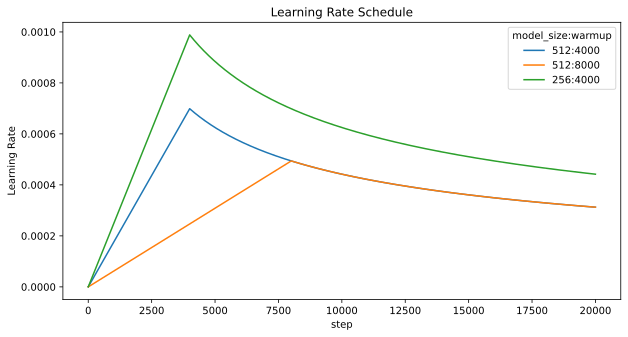

In [29]:
import matplotlib.pyplot as plt
import torch
from torch.optim.lr_scheduler import LambdaLR

def example_learning_schedule():
    opts = [
        [512, 1, 4000],
        [512, 1, 8000],
        [256, 1, 4000],
    ]
    labels = ["512:4000", "512:8000", "256:4000"]

    dummy_model = torch.nn.Linear(1, 1)

    plt.figure(figsize=(10, 5))

    for example, label in zip(opts, labels):
        optimizer = torch.optim.Adam(
            dummy_model.parameters(), lr=1, betas=(0.9, 0.98), eps=1e-9
        )
        lr_scheduler = LambdaLR(
            optimizer=optimizer,
            lr_lambda=lambda step, ex=example: rate(step, *ex)
        )

        lrs = []
        for step in range(20000):
            lrs.append(optimizer.param_groups[0]["lr"])
            optimizer.step()
            lr_scheduler.step()

        plt.plot(range(20000), lrs, label=label)

    plt.xlabel("step")
    plt.ylabel("Learning Rate")
    plt.title("Learning Rate Schedule")
    plt.legend(title="model_size:warmup")
    plt.show()

example_learning_schedule()


### 5.4 Regularization

We employ three types of regularization during training:


- **Residual Dropout:** We apply dropout [33] to the output of each sub-layer, before it is added to the sub-layer input and normalized. In addition, we apply dropout to the sums of the embeddings and the positional encodings in both the encoder and decoder stacks. For the base model, we use a rate of $P_{\text {drop }}=0.1$.

- **Label Smoothing:** During training, we employed label smoothing of value $\epsilon_{l s}=0.1$ [36]. This hurts perplexity, as the model learns to be more unsure, but improves accuracy and BLEU score.

> We implement label smoothing using the KL div loss. Instead of using a one-hot target distribution, we create a distribution that has confidence of the correct word and the rest of the smoothing mass distributed throughout the vocabulary.

In [30]:
class LabelSmoothing(nn.Module):
    "Implement label smoothing."

    def __init__(self, size, padding_idx, smoothing=0.0):
        super(LabelSmoothing, self).__init__()
        self.criterion = nn.KLDivLoss(reduction="sum")
        self.padding_idx = padding_idx
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.size = size
        self.true_dist = None

    def forward(self, x, target):
        assert x.size(1) == self.size
        true_dist = x.data.clone()
        true_dist.fill_(self.smoothing / (self.size - 2))
        true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        true_dist[:, self.padding_idx] = 0
        mask = torch.nonzero(target.data == self.padding_idx)
        if mask.dim() > 0:
            true_dist.index_fill_(0, mask.squeeze(), 0.0)
        self.true_dist = true_dist
        return self.criterion(x, true_dist.clone().detach())

> Here we can see an example of how the mass is distributed to the words based on confidence.

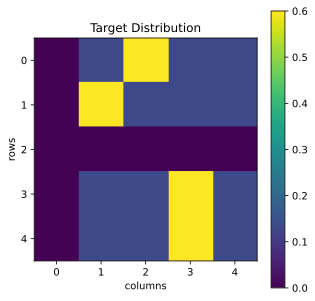

In [31]:
import matplotlib.pyplot as plt
import torch

def example_label_smoothing():
    crit = LabelSmoothing(5, 0, 0.4)
    predict = torch.FloatTensor(
        [
            [0, 0.2, 0.7, 0.1, 0],
            [0, 0.2, 0.7, 0.1, 0],
            [0, 0.2, 0.7, 0.1, 0],
            [0, 0.2, 0.7, 0.1, 0],
            [0, 0.2, 0.7, 0.1, 0],
        ]
    )

    crit(x=predict.log(), target=torch.LongTensor([2, 1, 0, 3, 3]))
    dist = crit.true_dist.cpu().numpy()

    plt.figure(figsize=(5, 5))
    plt.imshow(dist, origin="upper", aspect="equal")
    plt.xlabel("columns")
    plt.ylabel("rows")
    plt.title("Target Distribution")
    plt.colorbar()
    plt.xticks(range(5))
    plt.yticks(range(5))
    plt.show()

example_label_smoothing()

> Label smoothing actually starts to penalize the model if it gets very confident about a given choice.

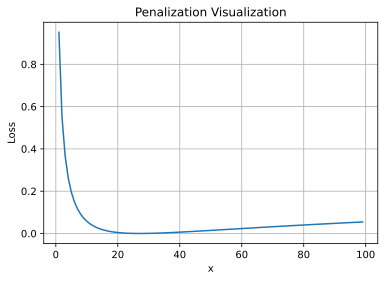

In [32]:
import matplotlib.pyplot as plt
import torch

def loss(x, crit):
    d = x + 3
    eps = 1e-9
    predict = torch.tensor([[eps, x / d, 1 / d, 1 / d, 1 / d]], dtype=torch.float32)
    predict = predict / predict.sum(dim=1, keepdim=True)
    return crit(predict.log(), torch.tensor([1], dtype=torch.long)).item()
    
def penalization_visualization():
    crit = LabelSmoothing(5, 0, 0.1)
    xs = list(range(1, 100))
    ys = [loss(x, crit) for x in xs]
    
    plt.figure(figsize=(6, 4))
    plt.plot(xs, ys)
    plt.xlabel("x")
    plt.ylabel("Loss")
    plt.title("Penalization Visualization")
    plt.grid(True)
    plt.show()

penalization_visualization()


## 5.0 First toy Example

> We can begin by trying out a simple copy-task. Given a random set of input symbols from a small vocabulary, the goal is to generate back those same symbols.

- **Synthetic Data:**

In [33]:
def data_gen(V, batch_size, nbatches):
    "Generate random data for a src-tgt copy task."
    for i in range(nbatches):
        data = torch.randint(1, V, size=(batch_size, 10))
        data[:, 0] = 1
        src = data.requires_grad_(False).clone().detach()
        tgt = data.requires_grad_(False).clone().detach()
        yield Batch(src, tgt, 0)

- **Loss Computation:**

In [34]:
class SimpleLossCompute:
    "A simple loss compute and train function."

    def __init__(self, generator, criterion):
        self.generator = generator
        self.criterion = criterion

    def __call__(self, x, y, norm):
        x = self.generator(x)
        sloss = (
            self.criterion(
                x.contiguous().view(-1, x.size(-1)), y.contiguous().view(-1)
            )
            / norm
        )
        return sloss.data * norm, sloss

- **Greedy Decoding:**

> This code predicts a translation using greedy decoding for simplicity.

In [35]:
def greedy_decode(model, src, src_mask, max_len, start_symbol):
    memory = model.encode(src, src_mask)
    ys = torch.zeros(1, 1).fill_(start_symbol).type_as(src.data)
    for i in range(max_len - 1):
        out = model.decode(
            memory, src_mask, ys, subsequent_mask(ys.size(1)).type_as(src.data)
        )
        prob = model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.data[0]
        ys = torch.cat(
            [ys, torch.zeros(1, 1).type_as(src.data).fill_(next_word)], dim=1
        )
    return ys

In [36]:
from tqdm.auto import tqdm

# Train the simple copy task.

def example_simple_model():
    V = 11
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    criterion = LabelSmoothing(size=V, padding_idx=0, smoothing=0.0).to(device)
    model = make_model(V, V, N=2).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(), lr=0.5, betas=(0.9, 0.98), eps=1e-9
    )
    lr_scheduler = LambdaLR(
        optimizer=optimizer,
        lr_lambda=lambda step: rate(
            step, model_size=model.src_embed[0].d_model, factor=1.0, warmup=400
        ),
    )

    batch_size = 32
    num_epochs = 5

    epoch_bar = tqdm(range(num_epochs), desc="Training epochs")
    for epoch in epoch_bar:
        model.train()
        train_loss, _ = run_epoch(
            data_gen(V, batch_size, num_epochs),
            model,
            SimpleLossCompute(model.generator, criterion),
            optimizer,
            lr_scheduler,
            mode="train",
            epoch=epoch,
            total=5,
        )

        model.eval()
        val_loss, _ = run_epoch(
            data_gen(V, batch_size, 5),
            model,
            SimpleLossCompute(model.generator, criterion),
            DummyOptimizer(),
            DummyScheduler(),
            mode="eval",
            epoch=epoch,
            total=5,
        )

        epoch_bar.set_postfix(
            train_loss=f"{train_loss.item():.4f}" if torch.is_tensor(train_loss) else f"{train_loss:.4f}",
            val_loss=f"{val_loss.item():.4f}" if torch.is_tensor(val_loss) else f"{val_loss:.4f}",
        )

    model.eval()
    src = torch.LongTensor([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]]).to(device)
    max_len = src.shape[1]
    src_mask = torch.ones(1, 1, max_len, device=device)
    print(greedy_decode(model, src, src_mask, max_len=max_len, start_symbol=0))

start = time.time()
execute_example(example_simple_model)
elapsed = time.time() - start
print(f"Total run time: {elapsed/60:.2f} minutes")

Training epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 0 [train]:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 0 [eval]:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 [train]:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 [eval]:   0%|          | 0/5 [00:00<?, ?it/s]

...

Epoch 3 [train]:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 3 [eval]:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 4 [train]:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 4 [eval]:   0%|          | 0/5 [00:00<?, ?it/s]

tensor([[ 0, 10, 10,  5,  8,  6,  3,  2,  8,  6]], device='cuda:0')
Total run time: 0.16 minutes


## 6. Results

### 6.1 Machine Translation

On the WMT 2014 English-to-German translation task, the big transformer model (Transformer (big) in Table 2) outperforms the best previously reported models (including ensembles) by more than 2.0 BLEU, establishing a new state-of-the-art BLEU score of 28.4. The configuration of this model is listed in the bottom line of Table 3. Training took 3.5 days on 8 P100 GPUs. Even our base model surpasses all previously published models and ensembles, at a fraction of the training cost of any of the competitive models.

On the WMT 2014 English-to-French translation task, our big model achieves a BLEU score of 41.0, outperforming all of the previously published single models, at less than $1 / 4$ the training cost of the previous state-of-the-art model. The Transformer (big) model trained for English-to-French used dropout rate $P_{\text {drop }}=0.1$, instead of 0.3 .
For the base models, we used a single model obtained by averaging the last 5 checkpoints, which were written at 10 -minute intervals. For the big models, we averaged the last 20 checkpoints. We used beam search with a beam size of 4 and length penalty $\alpha=0.6[38]$. These hyperparameters were chosen after experimentation on the development set. We set the maximum output length during inference to input length +50 , but terminate early when possible [38].

**Table 2:** The Transformer achieves better BLEU scores than previous state-of-the-art models on the English-to-German and English-to-French newstest2014 tests at a fraction of the training cost.

| Model                          | BLEU EN-DE | BLEU EN-FR | Cost EN-DE | Cost EN-FR |
|--------------------------------|------------|------------|------------|------------|
| ByteNet [18]                   | 23.75      |            |            |            |
| Deep-Att + PosUnk [39]         |            | 39.2       |            | $1.0 \times 10^{20}$ |
| GNMT + RL [38]                 | 24.6       | 39.92      | $2.3 \times 10^{19}$ | $1.4 \times 10^{20}$ |
| ConvS2S [9]                    | 25.16      | 40.46      | $9.6 \times 10^{18}$ | $1.5 \times 10^{20}$ |
| MoE [32]                       | 26.03      | 40.56      | $2.0 \times 10^{19}$ | $1.2 \times 10^{20}$ |
| Deep-Att + PosUnk Ensemble [39]|            | 40.4       |            | $8.0 \times 10^{20}$ |
| GNMT + RL Ensemble [38]        | 26.30      | 41.16      | $1.8 \times 10^{20}$ | $1.1 \times 10^{21}$ |
| ConvS2S Ensemble [9]           | 26.36      | $\mathbf{41.29}$ | $7.7 \times 10^{19}$ | $1.2 \times 10^{21}$ |
| Transformer (base model)       | 27.3       | 38.1       | $\mathbf{3.3 \times 10^{18}}$ |            |
| Transformer (big)              | $\mathbf{28.4}$ | $\mathbf{41.8}$ | $2.3 \times 10^{19}$ |            |

Table 2 summarizes our results and compares our translation quality and training costs to other model architectures from the literature. We estimate the number of floating point operations used to train a model by multiplying the training time, the number of GPUs used, and an estimate of the sustained single-precision floating-point capacity of each GPU ${ }^5$.

- Now we consider a real-world example using the Multi30k German-English Translation task. This task is much smaller than the WMT task considered in the paper, but it illustrates the whole system. We also show how to use multi-gpu processing to make it really fast.

- **Data loading:**
> We will load the dataset using torchtext and spacy for tokenization.

In [37]:
import os

os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
os.environ["HF_HOME"] = "/inspire/hdd/project/fdu-aidake-cfff/public/hf-home"
print(os.environ.get("HF_ENDPOINT"))

from datasets import load_dataset
wmt_ds = load_dataset("wmt14", "de-en")
print(wmt_ds)

https://hf-mirror.com
DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 4508785
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 3000
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 3003
    })
})


- **Building BPE tokenizer:**

In [38]:
import time
from tqdm.auto import tqdm
from tokenizers import Tokenizer, models, pre_tokenizers, processors
from tokenizers.trainers import BpeTrainer

def build_paper_tokenizer(ds):
    tokenizer = Tokenizer(models.BPE(unk_token="<unk>"))
    tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

    trainer = BpeTrainer(
        vocab_size=37000,
        special_tokens=["<blank>", "<s>", "</s>", "<unk>"]
    )

    total_examples = sum(len(ds[split]) for split in ["train", "validation", "test"])

    def batch_iterator():
        pbar = tqdm(total=2 * total_examples, desc="Training tokenizer")
        for split in ["train", "validation", "test"]:
            for example in ds[split]:
                yield example["translation"]["de"]
                pbar.update(1)
                yield example["translation"]["en"]
                pbar.update(1)
        pbar.close()

    tokenizer.train_from_iterator(batch_iterator(), trainer=trainer)

    tokenizer.post_processor = processors.TemplateProcessing(
        single="<s> $A </s>",
        pair="<s> $A </s> $B:1 </s>:1",
        special_tokens=[
            ("<s>", tokenizer.token_to_id("<s>")),
            ("</s>", tokenizer.token_to_id("</s>")),
        ],
    )
    return tokenizer

In [39]:
import time

start = time.time()
shared_tokenizer = build_paper_tokenizer(wmt_ds)
elapsed = time.time() - start

print("Vocab size:", shared_tokenizer.get_vocab_size())
print(f"Total run time: {elapsed/60:.2f} minutes")

Training tokenizer:   0%|          | 0/9029576 [00:00<?, ?it/s]




Vocab size: 37000
Total run time: 2.00 minutes


- **Dataset batching:**

> Batching matters a ton for speed. We want to have very evenly divided batches, with absolutely minimal padding. To do this we have to hack a bit around the default torchtext batching. This code patches their default batching to make sure we search over enough sentences to find tight batches.

In [44]:
import torch
from torch.nn.functional import pad
from torch.utils.data import DataLoader

def collate_batch(
    batch,
    tokenizer,
    device,
    max_padding=128,
    pad_id=None,
):
    if pad_id is None:
        pad_id = tokenizer.token_to_id("<blank>")

    src_list, tgt_list = [], []

    for _src, _tgt in batch:
        processed_src = torch.tensor(
            tokenizer.encode(_src).ids,
            dtype=torch.int64,
            device=device,
        )
        processed_tgt = torch.tensor(
            tokenizer.encode(_tgt).ids,
            dtype=torch.int64,
            device=device,
        )

        processed_src = processed_src[:max_padding]
        processed_tgt = processed_tgt[:max_padding]

        src_list.append(
            pad(processed_src, (0, max_padding - len(processed_src)), value=pad_id)
        )
        tgt_list.append(
            pad(processed_tgt, (0, max_padding - len(processed_tgt)), value=pad_id)
        )

    src = torch.stack(src_list)
    tgt = torch.stack(tgt_list)
    return src, tgt

def create_dataloaders(
    device,
    ds,
    tokenizer,
    batch_size=32,
    max_padding=128,
    is_distributed=False,
):
    def collate_fn(batch):
        text_batch = [
            (example["translation"]["de"], example["translation"]["en"])
            for example in batch
        ]
        return collate_batch(
            text_batch,
            tokenizer,
            device,
            max_padding=max_padding,
            pad_id=tokenizer.token_to_id("<blank>"),
        )

    train_dataloader = DataLoader(
        ds["train"],
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_fn,
    )

    valid_dataloader = DataLoader(
        ds["validation"],
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
    )

    return train_dataloader, valid_dataloader

- **Training the Transformer model for machine translation**

In [47]:
from tqdm.auto import tqdm

def train_worker(
    tokenizer,
    ds,
    config,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}", flush=True)

    pad_idx = tokenizer.token_to_id("<blank>")
    vocab_size = tokenizer.get_vocab_size()
    d_model = 512
    d_model = config["d_model"]
    model = make_model(
        vocab_size,
        vocab_size,
        N=config["N"],
        d_model=config["d_model"],
        d_ff=config["d_ff"],
        h=config["h"],
        dropout=config["dropout"],
    ).to(device)
    criterion = LabelSmoothing(
        size=vocab_size, padding_idx=pad_idx, smoothing=0.1
    ).to(device)

    train_dataloader, valid_dataloader = create_dataloaders(
        device=device,
        ds=ds,
        tokenizer=tokenizer,
        batch_size=config["batch_size"],
        max_padding=config["max_padding"],
        is_distributed=False,
    )

    optimizer = torch.optim.Adam(
        model.parameters(), lr=config["base_lr"], betas=(0.9, 0.98), eps=1e-9
    )
    lr_scheduler = LambdaLR(
        optimizer=optimizer,
        lr_lambda=lambda step: rate(
            step, d_model, factor=1, warmup=config["warmup"]
        ),
    )
    train_state = TrainState()

    for epoch in range(config["num_epochs"]):
        model.train()
        print(f"Epoch {epoch} Training ====", flush=True)
        _, train_state = run_epoch(
            (Batch(b[0], b[1], pad_idx) for b in train_dataloader),
            model,
            SimpleLossCompute(model.generator, criterion),
            optimizer,
            lr_scheduler,
            mode="train+log",
            accum_iter=config["accum_iter"],
            train_state=train_state,
            epoch=epoch,
            total=len(train_dataloader),
        )

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        file_path = "%s%.2d.pt" % (config["file_prefix"], epoch)
        torch.save(model.state_dict(), file_path)

        print(f"Epoch {epoch} Validation ====", flush=True)
        model.eval()
        sloss = run_epoch(
            (Batch(b[0], b[1], pad_idx) for b in valid_dataloader),
            model,
            SimpleLossCompute(model.generator, criterion),
            DummyOptimizer(),
            DummyScheduler(),
            mode="eval",
            epoch=epoch,
            total=len(valid_dataloader),
        )
        print(sloss)

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    file_path = "%sfinal.pt" % config["file_prefix"]
    torch.save(model.state_dict(), file_path)

- **Small model training**

In [ ]:
# small model training
import gc
import torch

print(torch.cuda.memory_allocated() / 1024**2, "MB allocated")
print(torch.cuda.memory_reserved() / 1024**2, "MB reserved")


for name in ["model", "optimizer", "batch", "loss", "outputs"]:
    if name in globals():
        del globals()[name]
gc.collect()
torch.cuda.empty_cache()

print(torch.cuda.memory_allocated() / 1024**2, "MB allocated")
print(torch.cuda.memory_reserved() / 1024**2, "MB reserved")


def train_model(tokenizer, wmt_ds, config):
    train_worker(tokenizer, wmt_ds, config)

def load_trained_model(sampling=True):
    config = {
        "batch_size": 64,
        "num_epochs": 3,
        "accum_iter": 10,
        "base_lr": 1.0,
        "max_padding": 72,
        "warmup": 3000,
        "file_prefix": "wmt14_small_",
        "N": 2,
        "d_model": 128,
        "d_ff": 512,
        "h": 4,
        "dropout": 0.1,
    }
    model_path = "wmt14_model_final.pt"
    if not os.path.exists(model_path):
        if sampling:
            train_model(shared_tokenizer, small_wmt_ds, config)
        else:
            train_model(shared_tokenizer, wmt_ds, config)
    vocab_size = shared_tokenizer.get_vocab_size()
    model = make_model(
        vocab_size,
        vocab_size,
        N=config["N"],
        d_model=config["d_model"],
        d_ff=config["d_ff"],
        h=config["h"],
        dropout=config["dropout"],
    )
    model.load_state_dict(torch.load(model_path, map_location="cpu"))

small_wmt_ds = wmt_ds.copy()
n_train = int(0.1 * len(wmt_ds["train"]))
small_wmt_ds["train"] = wmt_ds["train"].select(range(n_train))
if is_interactive_notebook():
    model = load_trained_model(sampling=True) # just use 10% of the training data

903.85205078125 MB allocated
4940.0 MB reserved
903.85205078125 MB allocated
1624.0 MB reserved
Using device: cuda
Epoch 0 Training ====


Epoch 0 [train+log]:   0%|          | 0/7045 [00:00<?, ?it/s]

Epoch 0 Validation ====


Epoch 0 [eval]:   0%|          | 0/47 [00:00<?, ?it/s]

(tensor(4.4241, device='cuda:0'), <__main__.TrainState object at 0x7f3ed6788da0>)
Epoch 1 Training ====


Epoch 1 [train+log]:   0%|          | 0/7045 [00:00<?, ?it/s]

Epoch 1 Validation ====


Epoch 1 [eval]:   0%|          | 0/47 [00:00<?, ?it/s]

(tensor(3.8747, device='cuda:0'), <__main__.TrainState object at 0x7f3ed6788da0>)
Epoch 2 Training ====


Epoch 2 [train+log]:   0%|          | 0/7045 [00:00<?, ?it/s]

> Once trained we can decode the model to produce a set of translations. Here we simply translate the first sentence in the validation set. This dataset is pretty small so the translations with greedy search are reasonably accurate.

> Shared Embeddings: When using BPE with shared vocabulary we can share the same weight vectors between the source / target / generator. See the (cite) for details. To add this to the model simply do this:

### 6.2 Model Variations

To evaluate the importance of different components of the Transformer, we varied our base model in different ways, measuring the change in performance on English-to-German translation on the development set, newstest2013. We used beam search as described in the previous section, but no checkpoint averaging. We present these results in Table 3.

**Table 3:** Variations on the Transformer architecture. Unlisted values are identical to those of the base model. All metrics are on the English-to-German translation development set, newstest2013.

| Variant | N | d_model | d_ff | h | d_k | d_v | P_drop | $\epsilon_\text{ls}$ | train steps | PPL (dev) | BLEU (dev) | params (M) |
|--------|---|--------|------|---|-----|-----|--------|------|-------------|-----------|------------|------------|
| base   | 6 | 512    | 2048 | 8 | 64  | 64  | 0.1    | 0.1  | 100K        | 4.92      | 25.8       | 65         |
| (A) h=1  |   |      |      | 1  | 512 | 512 |        |      |             | 5.29      | 24.9       |            |
| (A) h=4  |   |      |      | 4  | 128 | 128 |        |      |             | 5.00      | 25.5       |            |
| (A) h=16 |   |      |      | 16 | 32  | 32  |        |      |             | 4.91      | 25.8       |            |
| (A) h=32 |   |      |      | 32 | 16  | 16  |        |      |             | 5.01      | 25.4       |            |
| (B) d_k=d_v=16 |   |      |      |   | 16  | 16  |        |      |             | 5.16      | 25.1       | 58         |
| (B) d_k=d_v=32 |   |      |      |   | 32  | 32  |        |      |             | 5.01      | 25.4       | 60         |
| (C) N=2   | 2 |      |      |   |     |     |        |      |             | 6.11      | 23.7       | 36         |
| (C) N=4   | 4 |      |      |   |     |     |        |      |             | 5.19      | 25.3       | 50         |
| (C) N=8   | 8 |      |      |   |     |     |        |      |             | 4.88      | 25.5       | 80         |
| (C) d_model=256 |   | 256  |      |   | 32  | 32  |        |      |             | 5.75      | 24.5       | 28         |
| (C) d_model=1024|   | 1024 |      |   | 128 | 128 |        |      |             | 4.66      | 26.0       | 168        |
| (C) d_ff=1024   |   |      | 1024 |   |     |     |        |      |             | 5.12      | 25.4       | 53         |
| (C) d_ff=4096   |   |      | 4096 |   |     |     |        |      |             | 4.75      | 26.2       | 90         |
| (D) dropout=0.0 |   |      |      |   |     |     | 0.0    |      |             | 5.77      | 24.6       |            |
| (D) dropout=0.2 |   |      |      |   |     |     | 0.2    |      |             | 4.95      | 25.5       |            |
| (D) $\epsilon_\text{ls}$=0.0    |   |      |      |   |     |     |        | 0.0  |             | 4.67      | 25.3       |            |
| (D) $\epsilon_\text{ls}$=0.2    |   |      |      |   |     |     |        | 0.2  |             | 5.47      | 25.7       |            |
| (E) learned positional embeddings |   |      |      |   |     |     |        |      |             | 4.92      | 25.7       |            |
| big | 6 | 1024 | 4096 | 16 |     |     | 0.3 |      | 300K | **4.33** | **26.4** | 213 |

In Table 3 rows (A), we vary the number of attention heads and the attention key and value dimensions, keeping the amount of computation constant, as described in Section 3.2.2. While single-head attention is 0.9 BLEU worse than the best setting, quality also drops off with too many heads.

In Table 3 rows (B), we observe that reducing the attention key size $d_k$ hurts model quality. This suggests that determining compatibility is not easy and that a more sophisticated compatibility function than dot product may be beneficial. We further observe in rows (C) and (D) that, as expected, bigger models are better, and dropout is very helpful in avoiding over-fitting. In row (E) we replace our sinusoidal positional encoding with learned positional embeddings [9], and observe nearly identical results to the base model.

### 6.3 English Constituency Parsing

To evaluate if the Transformer can generalize to other tasks we performed experiments on English constituency parsing. This task presents specific challenges: the output is subject to strong structural constraints and is significantly longer than the input. Furthermore, RNN sequence-to-sequence models have not been able to attain state-of-the-art results in small-data regimes [[37](https://baojian.github.io/llm-26/papers/Transformer-ref37-NIPS-2015-grammar-as-a-foreign-language-Paper.pdf)].

We trained a 4-layer transformer with $d_{\text {model }}=1024$ on the Wall Street Journal (WSJ) portion of the [Penn Treebank](https://baojian.github.io/llm-26/papers/Transformer-ref25-J93-2004.pdf), about 40 K training sentences. We also trained it in a semi-supervised setting, using the larger high-confidence and BerkleyParser corpora from with approximately 17 M sentences [[37](https://baojian.github.io/llm-26/papers/Transformer-ref37-NIPS-2015-grammar-as-a-foreign-language-Paper.pdf)]. We used a vocabulary of 16 K tokens for the WSJ only setting and a vocabulary of 32 K tokens for the semi-supervised setting.

We performed only a small number of experiments to select the dropout, both attention and residual (section 5.4), learning rates and beam size on the Section 22 development set, all other parameters remained unchanged from the English-to-German base translation model. During inference, we increased the maximum output length to input length +300 . We used a beam size of 21 and $\alpha=0.3$ for both WSJ only and the semi-supervised setting.

**Table 4:** The Transformer generalizes well to English constituency parsing (Results are on Section 23 of WSJ)

| Parser                              | Training                     | WSJ 23 F1 |
|------------------------------------|------------------------------|-----------|
| Vinyals & Kaiser et al. (2014) [37] | WSJ only, discriminative     | 88.3      |
| Petrov et al. (2006) [29]           | WSJ only, discriminative     | 90.4      |
| Zhu et al. (2013) [40]              | WSJ only, discriminative     | 90.4      |
| Dyer et al. (2016) [8]              | WSJ only, discriminative     | 91.7      |
| Transformer (4 layers)              | WSJ only, discriminative     | 91.3      |
| | | |
| Zhu et al. (2013) [40]              | semi-supervised              | 91.3      |
| Huang & Harper (2009) [14]          | semi-supervised              | 91.3      |
| McClosky et al. (2006) [26]         | semi-supervised              | 92.1      |
| Vinyals & Kaiser et al. (2014) [37] | semi-supervised              | 92.1      |
| Transformer (4 layers)              | semi-supervised              | **92.7**  |
| | | |
| Luong et al. (2015) [23]            | multi-task                   | 93.0      |
| Dyer et al. (2016) [8]              | generative                   | 93.3      |

Our results in Table 4 show that despite the lack of task-specific tuning our model performs surprisingly well, yielding better results than all previously reported models with the exception of the [Recurrent Neural Network Grammar](https://baojian.github.io/llm-26/papers/Transformer-ref08-D16-1180.pdf).

In contrast to [RNN sequence-to-sequence models](https://baojian.github.io/llm-26/papers/Transformer-ref37-NIPS-2015-grammar-as-a-foreign-language-Paper.pdf), the Transformer outperforms the [BerkeleyParser](https://baojian.github.io/llm-26/papers/Transformer-ref29-P06-1055.pdf) even when training only on the WSJ training set of 40 K sentences.

## 7. Conclusion

In this work, we presented the Transformer, the first sequence transduction model based entirely on attention, replacing the recurrent layers most commonly used in encoder-decoder architectures with multi-headed self-attention.

For translation tasks, the Transformer can be trained significantly faster than architectures based on recurrent or convolutional layers. On both WMT 2014 English-to-German and WMT 2014 English-to-French translation tasks, we achieve a new state of the art. In the former task our best model outperforms even all previously reported ensembles.

We are excited about the future of attention-based models and plan to apply them to other tasks. We plan to extend the Transformer to problems involving input and output modalities other than text and to investigate local, restricted attention mechanisms to efficiently handle large inputs and outputs such as images, audio and video. Making generation less sequential is another research goals of ours.
The code we used to train and evaluate our models is available at [https://github.com/tensorflow/tensor2tensor](https://github.com/tensorflow/tensor2tensor).